# Обзор результатов


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image

root = Path.cwd()
if not (root / "report_results").exists():
    for p in root.parents:
        if (p / "report_results").exists():
            root = p
            break

table_dir = root / "report_results" / "tables"
fig_dir = root / "report_results" / "figures"

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 55)

def read_table(name):
    return pd.read_csv(table_dir / name)

def show_img(name):
    p = fig_dir / name
    if p.exists():
        display(Image(filename=str(p)))

case_names = {
    "heat_alpha01": "Heat, alpha=0.1",
    "helmholtz_m12_long": "Helmholtz, m=12",
    "helmholtz_m12_rs": "Helmholtz, m=12, resampling",
    "helmholtz_m12_resample128": "Helmholtz, m=12, long L-BFGS",
    "helmholtz_m7_rs": "Helmholtz, m=7",
    "helmholtz_m8_rs": "Helmholtz, m=8",
    "helmholtz_m10_resample128": "Helmholtz, m=10",
    "helmholtz_m11_rs": "Helmholtz, m=11",
    "convection_beta30": "Convection, beta=30",
    "convection_beta50": "Convection, beta=50, diagnostic",
    "burgers_nu0p002": "Burgers, delta=0.002",
    "burgers_nu0p001": "Burgers, delta=0.001",
    "fp16_summary": "FP16 failure cases",
}

def add_names(df):
    df = df.copy()
    if "case_id" in df.columns:
        df["name"] = df["case_id"].map(case_names).fillna(df["case_id"])
    return df


## Запуски

In [2]:
runs = read_table("all_runs_normalized.csv")
overview = read_table("task_overview.csv")

summary = pd.DataFrame({
    "метрика": ["всего запусков", "валидных", "плохих или невалидных", "задачи", "dtype"],
    "значение": [
        len(runs),
        int(runs["is_valid"].sum()),
        int(runs["is_bad"].sum()),
        ", ".join(sorted(runs["task_name"].dropna().unique())),
        ", ".join(sorted(runs["dtype"].dropna().unique())),
    ],
})
summary


,метрика,значение
0,всего запусков,443
1,валидных,423
2,плохих или невалидных,162
3,задачи,"burgers1d, convection1d, heat1d, helmholtz1d"
4,dtype,"fp16, fp32, fp64"


In [3]:
cols = [
    "task_name", "main_parameter_name", "main_parameter_value", "dtype",
    "n_total", "n_valid", "n_bad", "median_best_l2", "bad_rate",
]
overview[cols].sort_values(["task_name", "main_parameter_value", "dtype"]).head(20)


,task_name,main_parameter_name,main_parameter_value,dtype,n_total,n_valid,n_bad,median_best_l2,bad_rate
0,burgers1d,nu,0.0001,fp32,2,2,0,0.401003,0.0
1,burgers1d,nu,0.0001,fp64,2,2,0,0.413677,0.0
2,burgers1d,nu,0.0002,fp32,2,2,0,0.397256,0.0
3,burgers1d,nu,0.0002,fp64,2,2,0,0.408756,0.0
4,burgers1d,nu,0.0005,fp32,2,2,0,0.385514,0.0
5,burgers1d,nu,0.0005,fp64,2,2,0,0.383942,0.0
6,burgers1d,nu,0.0010,fp16,4,0,4,NaN,1.0
7,burgers1d,nu,0.0010,fp32,16,16,0,0.231896,0.0
8,burgers1d,nu,0.0010,fp64,16,16,0,0.232790,0.0
9,burgers1d,nu,0.0020,fp16,4,0,4,NaN,1.0


## Heat


In [4]:
main_cases = read_table("report_main_cases.csv")
heat = main_cases[main_cases["task"] == "heat1d"]
heat_view = add_names(heat)
heat_view[[
    "name", "parameter", "n_seed_fp32", "n_seed_fp64",
    "fp32_median_best_l2", "fp64_median_best_l2", "ratio",
]]


,name,parameter,n_seed_fp32,n_seed_fp64,fp32_median_best_l2,fp64_median_best_l2,ratio
0,"Heat, alpha=0.1",alpha=0.1,3.0,3.0,0.000375,0.000311,0.827905


## Helmholtz


In [5]:
helm = read_table("report_helmholtz_cases.csv")
helm_view = add_names(helm)
helm_view[[
    "name", "parameter", "n_seed_fp32", "n_seed_fp64",
    "fp32_median_best_l2", "fp64_median_best_l2", "ratio",
    "bad_rate_fp32", "bad_rate_fp64",
]]


,name,parameter,n_seed_fp32,n_seed_fp64,fp32_median_best_l2,fp64_median_best_l2,ratio,bad_rate_fp32,bad_rate_fp64
0,"Helmholtz, m=12",m=12,2,2,0.012531,0.002114,0.168675,0.0,0.0
1,"Helmholtz, m=12, resampling",m=12,2,2,0.002160,0.000834,0.386118,0.0,0.0
2,"Helmholtz, m=12, long L-BFGS",m=12,2,2,0.009213,0.002114,0.229403,0.0,0.0
3,"Helmholtz, m=7",m=7,2,2,0.001348,0.000514,0.381523,0.0,0.0
4,"Helmholtz, m=8",m=8,2,2,0.002536,0.001039,0.409678,0.0,0.0
5,"Helmholtz, m=10",m=10,2,2,0.002986,0.001513,0.506824,0.0,0.0
6,"Helmholtz, m=11",m=11,2,2,0.001906,0.000983,0.516015,0.0,0.0


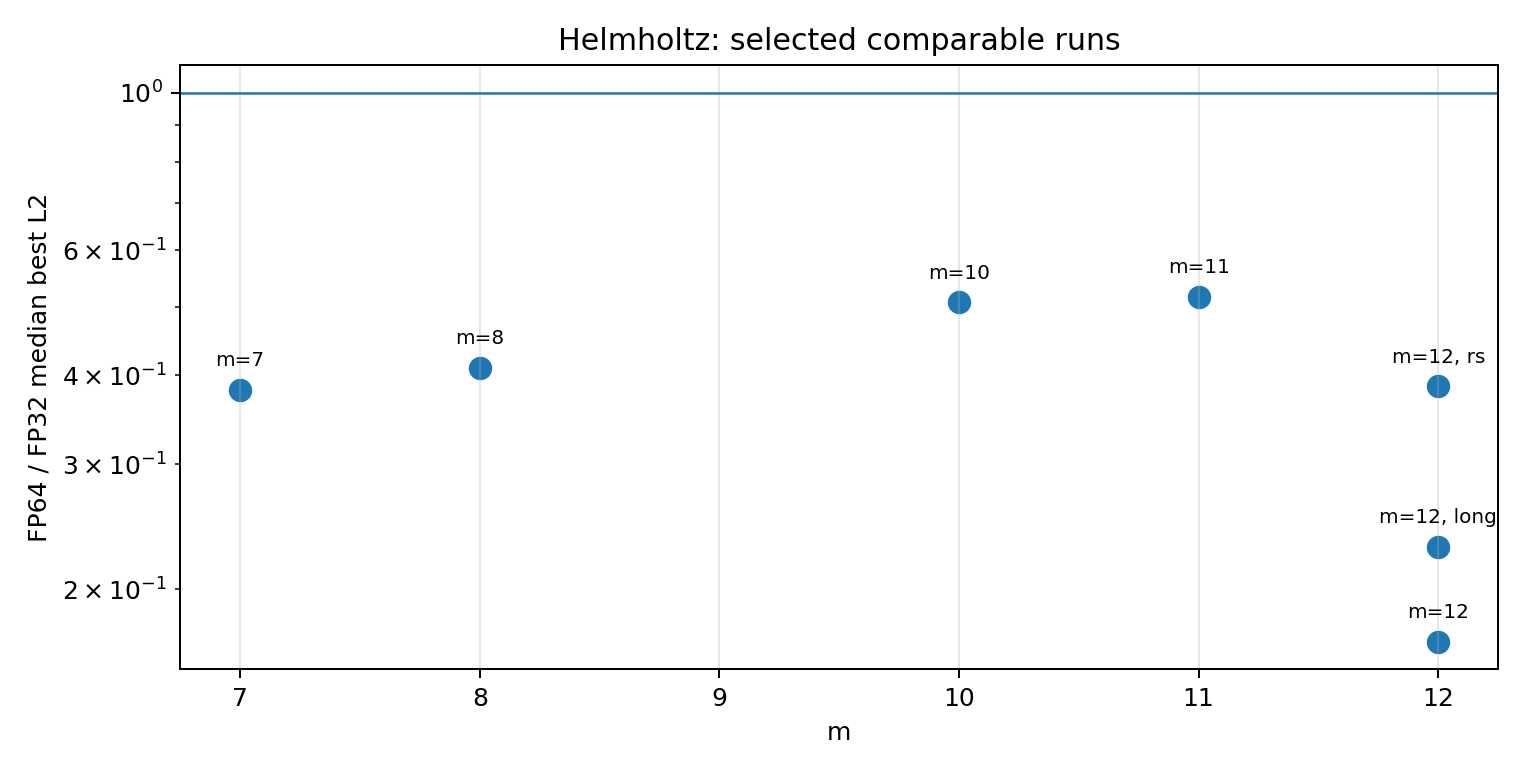

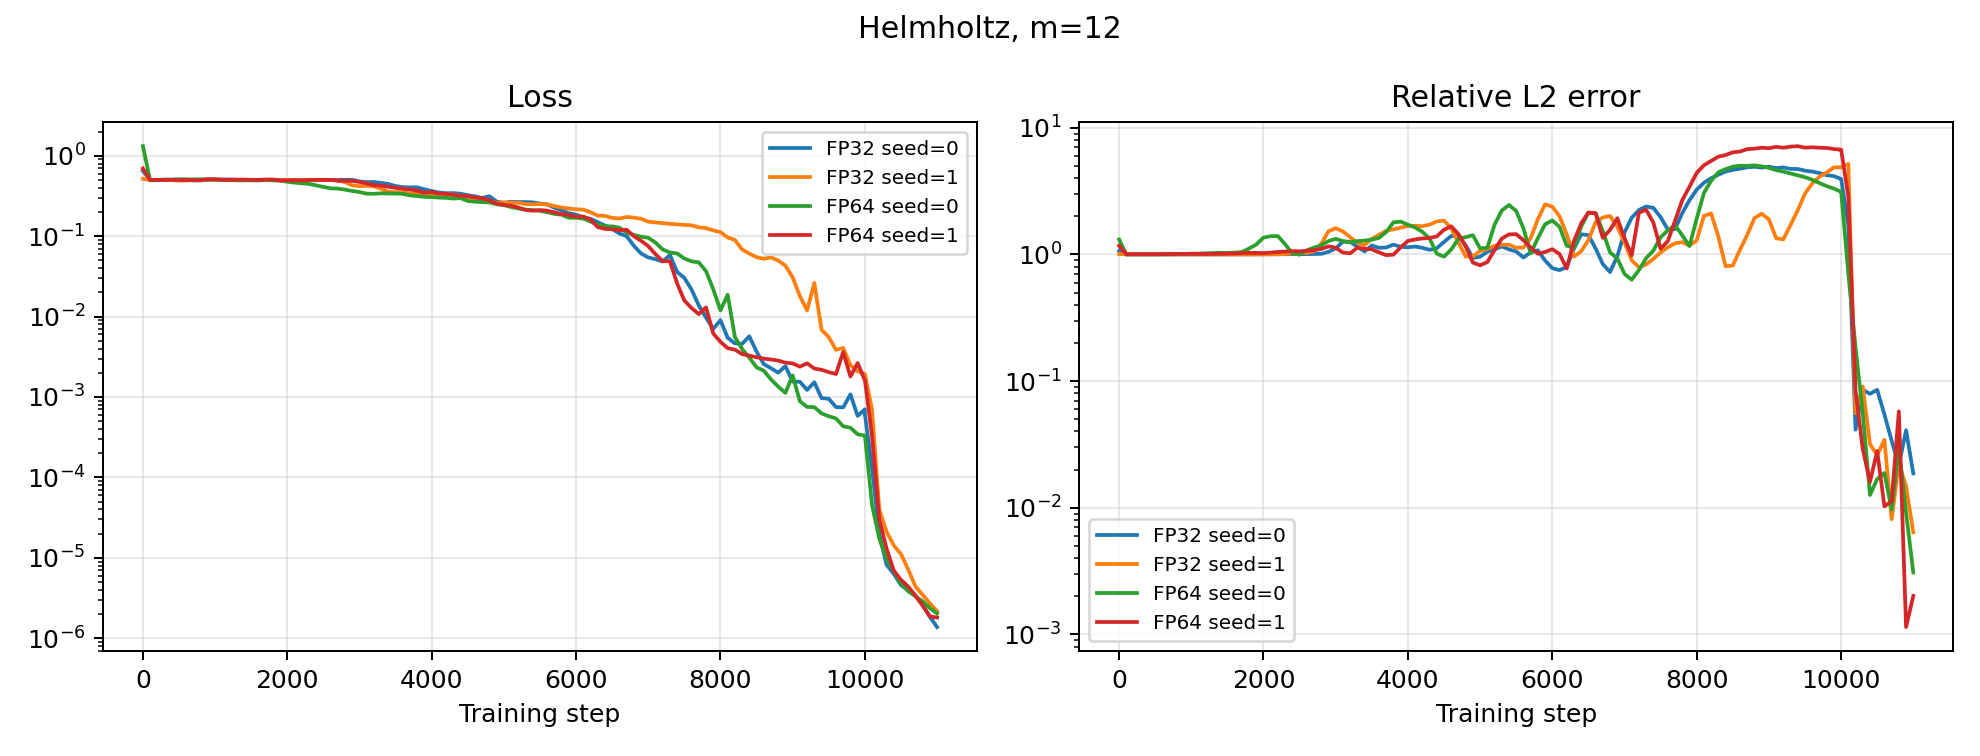

In [6]:
show_img("report_helmholtz_ratio.png")
show_img("report_helmholtz_rs_sweep.png")
show_img("report_helmholtz_m12_curves.png")


In [7]:
comp = read_table("fp32_fp64_comparison.csv")
helm_all = comp[comp["task_name"] == "helmholtz1d"].copy()
helm_all = helm_all[
    helm_all["main_parameter_value"].isin([5, 7, 8, 10, 11, 12, 15, 20, 30, 40])
]
cols = [
    "main_parameter_value", "fp32_n_valid", "fp64_n_valid",
    "fp32_median_best_l2", "fp64_median_best_l2", "fp64_over_fp32_median",
    "fp32_bad_rate", "fp64_bad_rate"
]
helm_all[cols].sort_values(["main_parameter_value"]).head(15)


,main_parameter_value,fp32_n_valid,fp64_n_valid,fp32_median_best_l2,fp64_median_best_l2,fp64_over_fp32_median,fp32_bad_rate,fp64_bad_rate
26,5.0,2,2,0.001769,0.000634,0.358395,0.0,0.0
27,5.0,2,2,0.000082,0.000059,0.721432,0.0,0.0
28,5.0,2,2,0.000150,0.000478,3.181760,0.0,0.0
30,7.0,2,2,0.001348,0.000514,0.381523,0.0,0.0
47,8.0,2,2,0.002788,0.115449,41.409572,0.0,0.0
46,8.0,1,1,0.002232,0.001076,0.481947,0.0,0.0
45,8.0,2,2,0.002536,0.001039,0.409678,0.0,0.0
44,8.0,2,2,0.003250,0.115449,35.524190,0.0,0.0
43,8.0,2,2,0.501915,0.000881,0.001756,0.5,0.0
42,8.0,2,2,0.500523,0.518273,1.035463,0.5,0.5


## Burgers


In [8]:
burg = comp[comp["task_name"] == "burgers1d"].copy()
cols = [
    "main_parameter_value", "fp32_n_valid", "fp64_n_valid",
    "fp32_median_best_l2", "fp64_median_best_l2", "fp64_over_fp32_median",
    "fp32_bad_rate", "fp64_bad_rate"
]
burg[cols].sort_values(["main_parameter_value"]).head(15)


,main_parameter_value,fp32_n_valid,fp64_n_valid,fp32_median_best_l2,fp64_median_best_l2,fp64_over_fp32_median,fp32_bad_rate,fp64_bad_rate
0,0.0001,2,2,0.401003,0.413677,1.031607,0.0,0.0
1,0.0002,2,2,0.397256,0.408756,1.028948,0.0,0.0
2,0.0005,2,2,0.385514,0.383942,0.995923,0.0,0.0
3,0.0010,2,2,0.258090,0.253003,0.980291,0.0,0.0
4,0.0010,3,3,0.226545,0.185780,0.820057,0.0,0.0
5,0.0010,4,4,0.248230,0.139175,0.560667,0.0,0.0
6,0.0010,3,3,0.312531,0.395074,1.264111,0.0,0.0
7,0.0010,2,2,0.327049,0.286945,0.877375,0.0,0.0
8,0.0010,2,2,0.094845,0.169969,1.792065,0.0,0.0
13,0.0020,2,2,0.048779,0.046524,0.953769,0.0,0.0


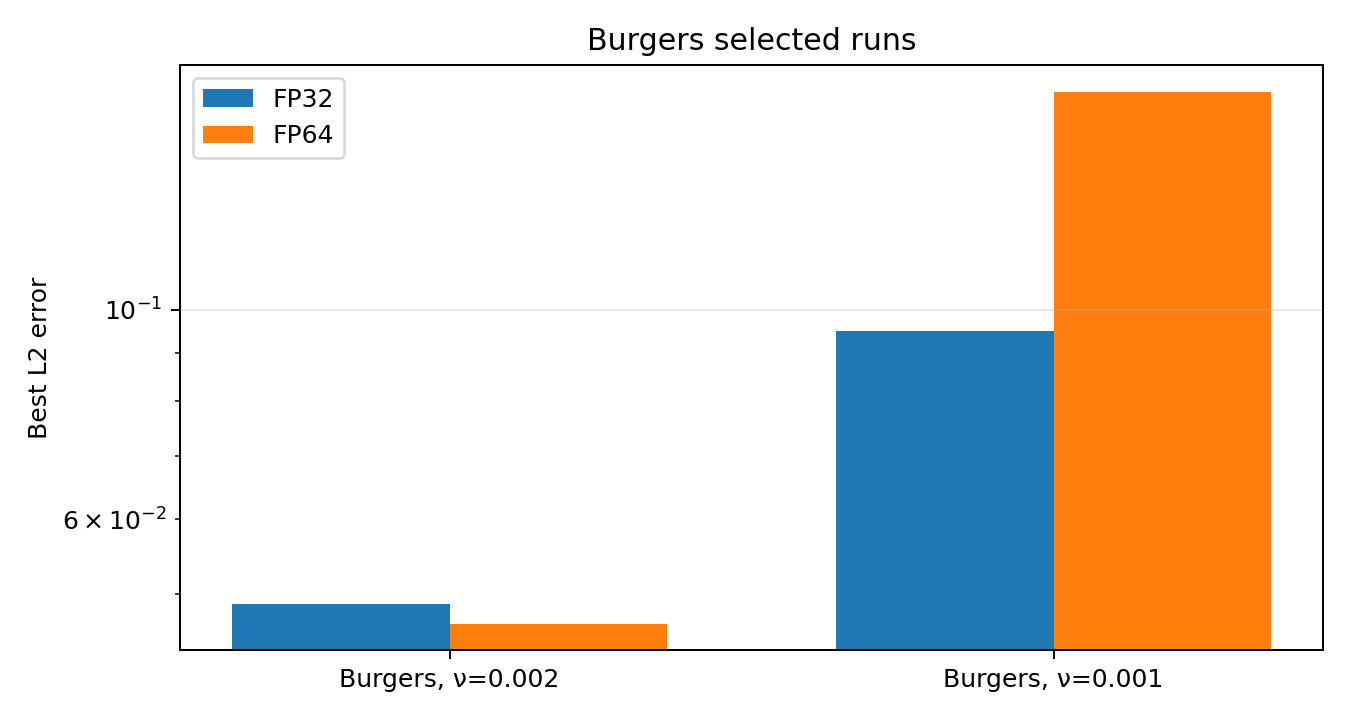

In [9]:
show_img("report_burgers_summary.png")


## Convection

In [10]:
conv = comp[comp["task_name"] == "convection1d"].copy()
conv_main = conv[conv["main_parameter_value"].eq(30)].copy()
cols = [
    "main_parameter_value", "fp32_n_valid", "fp64_n_valid",
    "fp32_median_best_l2", "fp64_median_best_l2", "fp64_over_fp32_median",
    "fp32_bad_rate", "fp64_bad_rate"
]
conv_main[cols].sort_values(["main_parameter_value"]).head(10)


,main_parameter_value,fp32_n_valid,fp64_n_valid,fp32_median_best_l2,fp64_median_best_l2,fp64_over_fp32_median,fp32_bad_rate,fp64_bad_rate
19,30.0,1,1,0.006611,0.010181,1.539935,0.0,0.0
20,30.0,2,2,1.000190,0.007463,0.007462,1.0,0.0
21,30.0,2,2,0.010941,0.006625,0.605541,0.0,0.0


In [11]:
diag = read_table("report_diagnostic_cases.csv")
diag_view = add_names(diag)
diag_view[[
    "name", "parameter", "n_seed_fp32", "n_seed_fp64",
    "fp32_median_best_l2", "fp64_median_best_l2", "ratio",
]]


,name,parameter,n_seed_fp32,n_seed_fp64,fp32_median_best_l2,fp64_median_best_l2,ratio
0,"Convection, beta=50, diagnostic",beta=50,1,1,0.687307,0.007182,0.010449
1,helmholtz_m8_main_old,m=8,2,2,0.501915,0.000881,0.001756
2,helmholtz_m15_hard,m=15,2,2,0.999106,0.999802,1.000697


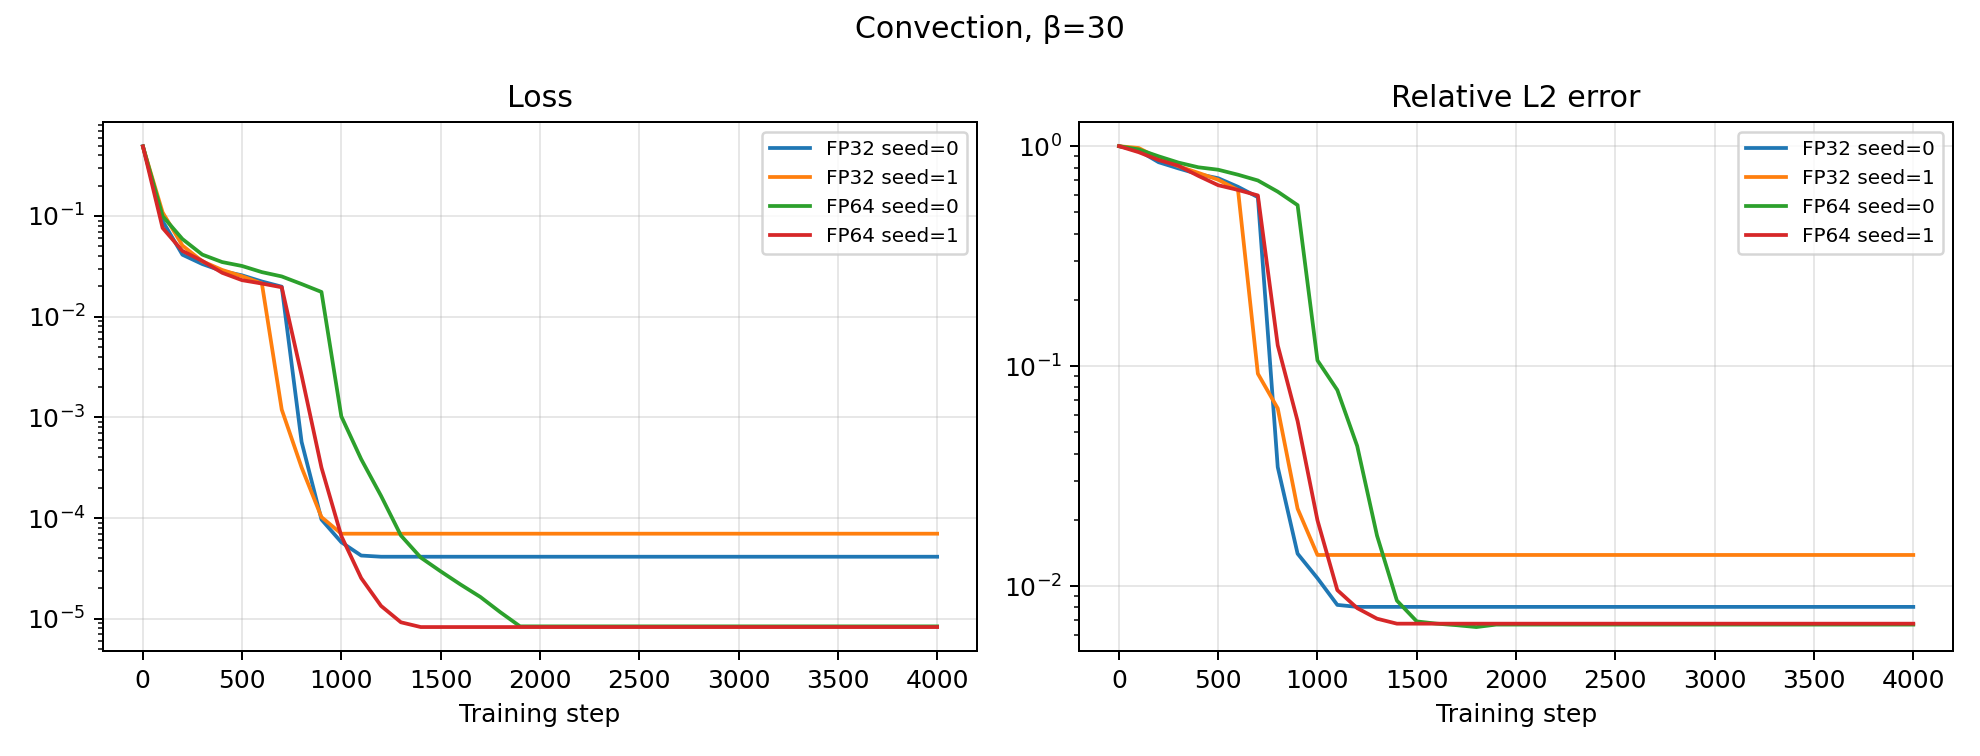

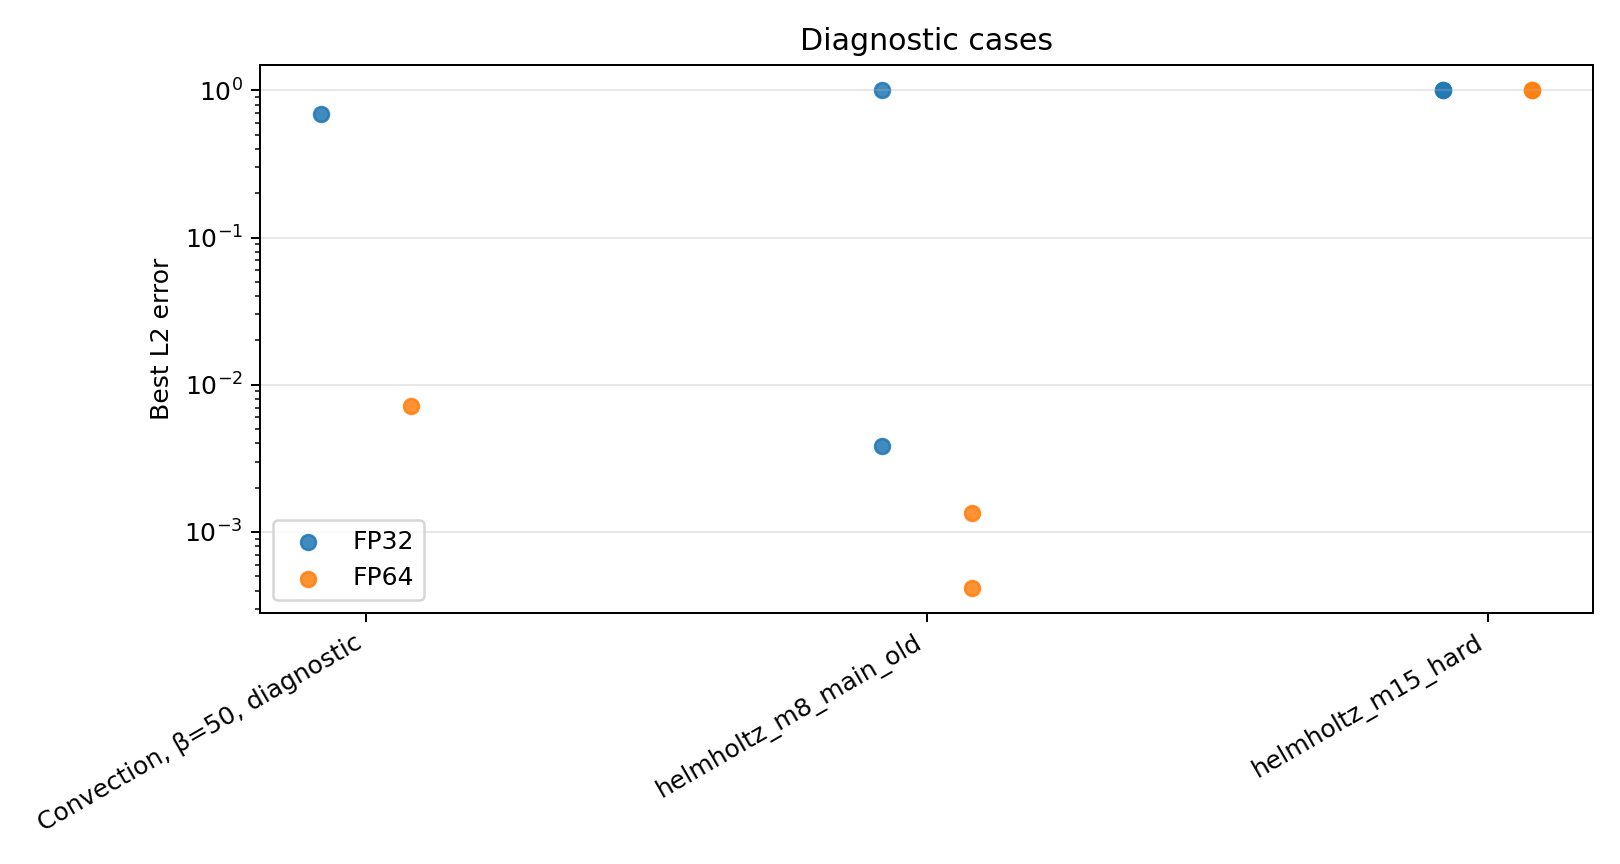

In [12]:
show_img("report_convection_beta30_curves.png")
show_img("report_diagnostic_seed_sensitive.png")


## FP16

In [13]:
fp16 = read_table("fp16_summary.csv")
reason_col = fp16.columns[-1]
fp16_view = fp16[[
    "task_name", "main_parameter_name", "main_parameter_value",
    "n_total", "n_valid", "n_bad", "bad_rate"
]]
fp16_view


,task_name,main_parameter_name,main_parameter_value,n_total,n_valid,n_bad,bad_rate
0,burgers1d,nu,0.001,4,0,4,1.0
1,burgers1d,nu,0.002,4,0,4,1.0
2,convection1d,beta,30.000,4,1,4,1.0
3,convection1d,beta,50.000,2,1,2,1.0
4,helmholtz1d,m,8.000,4,0,4,1.0
5,helmholtz1d,m,12.000,4,0,4,1.0


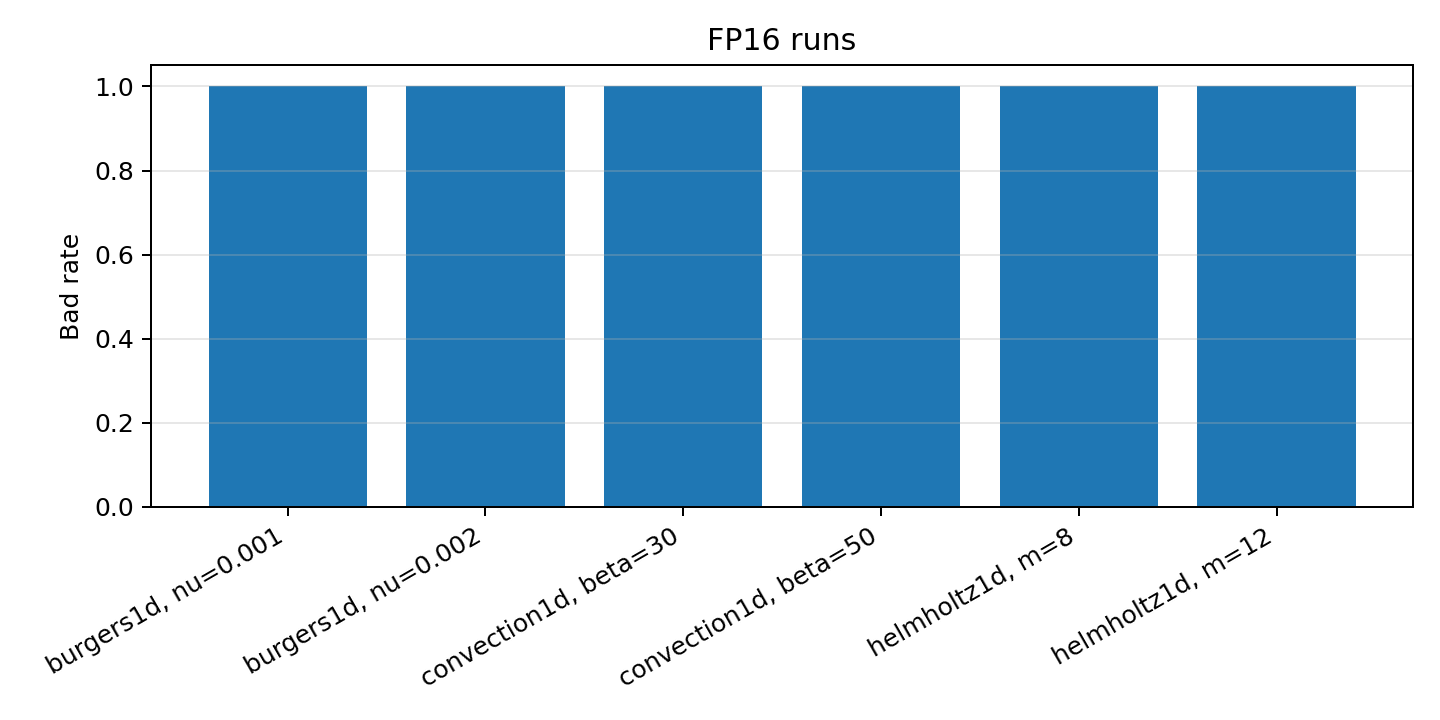

In [14]:
show_img("report_fp16_summary.png")


## Итоговые результаты


In [15]:
main_view = add_names(main_cases)
main_view[[
    "name", "task", "parameter", "n_seed_fp32", "n_seed_fp64",
    "fp32_median_best_l2", "fp64_median_best_l2", "ratio",
    "bad_rate_fp32", "bad_rate_fp64", "label",
]]


,name,task,parameter,n_seed_fp32,n_seed_fp64,fp32_median_best_l2,fp64_median_best_l2,ratio,bad_rate_fp32,bad_rate_fp64,label
0,"Heat, alpha=0.1",heat1d,alpha=0.1,3.0,3.0,0.000375,0.000311,0.827905,0.0,0.0,проверка
1,"Helmholtz, m=12",helmholtz1d,m=12,2.0,2.0,0.012531,0.002114,0.168675,0.0,0.0,главный положительный пример
2,"Helmholtz, m=12, resampling",helmholtz1d,m=12,2.0,2.0,0.002160,0.000834,0.386118,0.0,0.0,дополнительный чистый пример
3,"Helmholtz, m=12, long L-BFGS",helmholtz1d,m=12,2.0,2.0,0.009213,0.002114,0.229403,0.0,0.0,дополнительный чистый пример
4,"Helmholtz, m=7",helmholtz1d,m=7,2.0,2.0,0.001348,0.000514,0.381523,0.0,0.0,положительный пример
5,"Helmholtz, m=11",helmholtz1d,m=11,2.0,2.0,0.001906,0.000983,0.516015,0.0,0.0,умеренно положительный пример
6,"Convection, beta=30",convection1d,beta=30,2.0,2.0,0.010941,0.006625,0.605541,0.0,0.0,аккуратный пример convection
7,"Burgers, delta=0.002",burgers1d,nu=0.002,2.0,2.0,0.048779,0.046524,0.953769,0.0,0.0,результаты близкие
8,"Burgers, delta=0.001",burgers1d,nu=0.001,2.0,2.0,0.094845,0.169969,1.792065,0.0,0.0,смешанный результат
9,FP16 failure cases,fp16,все fp16-запуски,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FP16 нестабилен


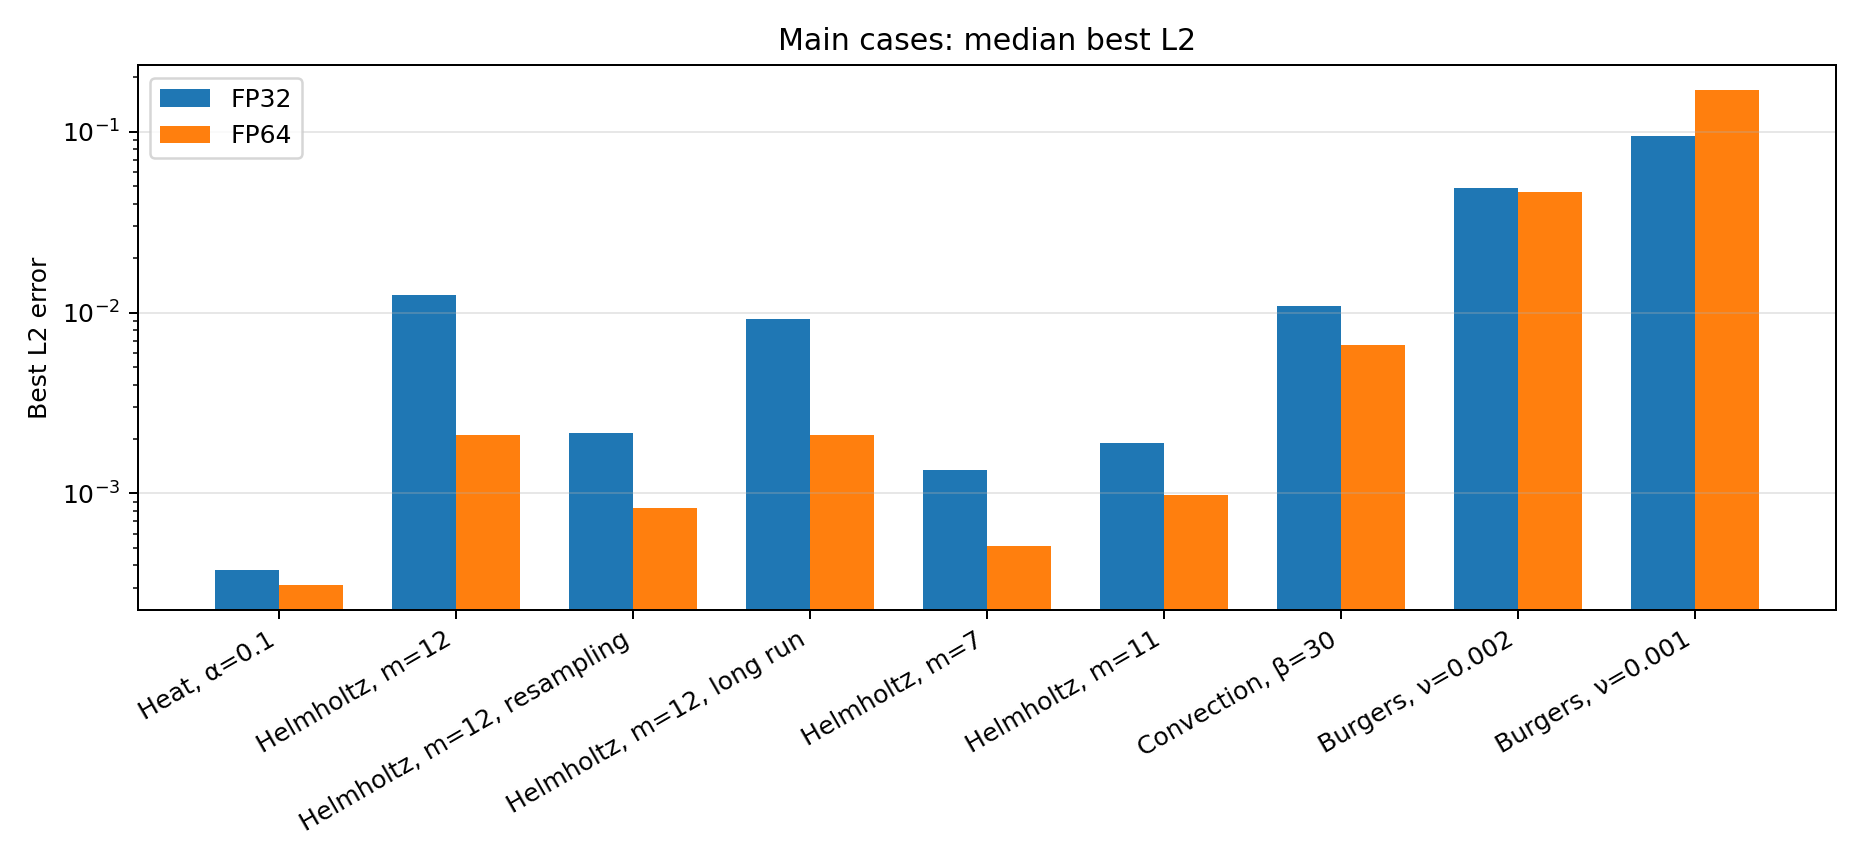

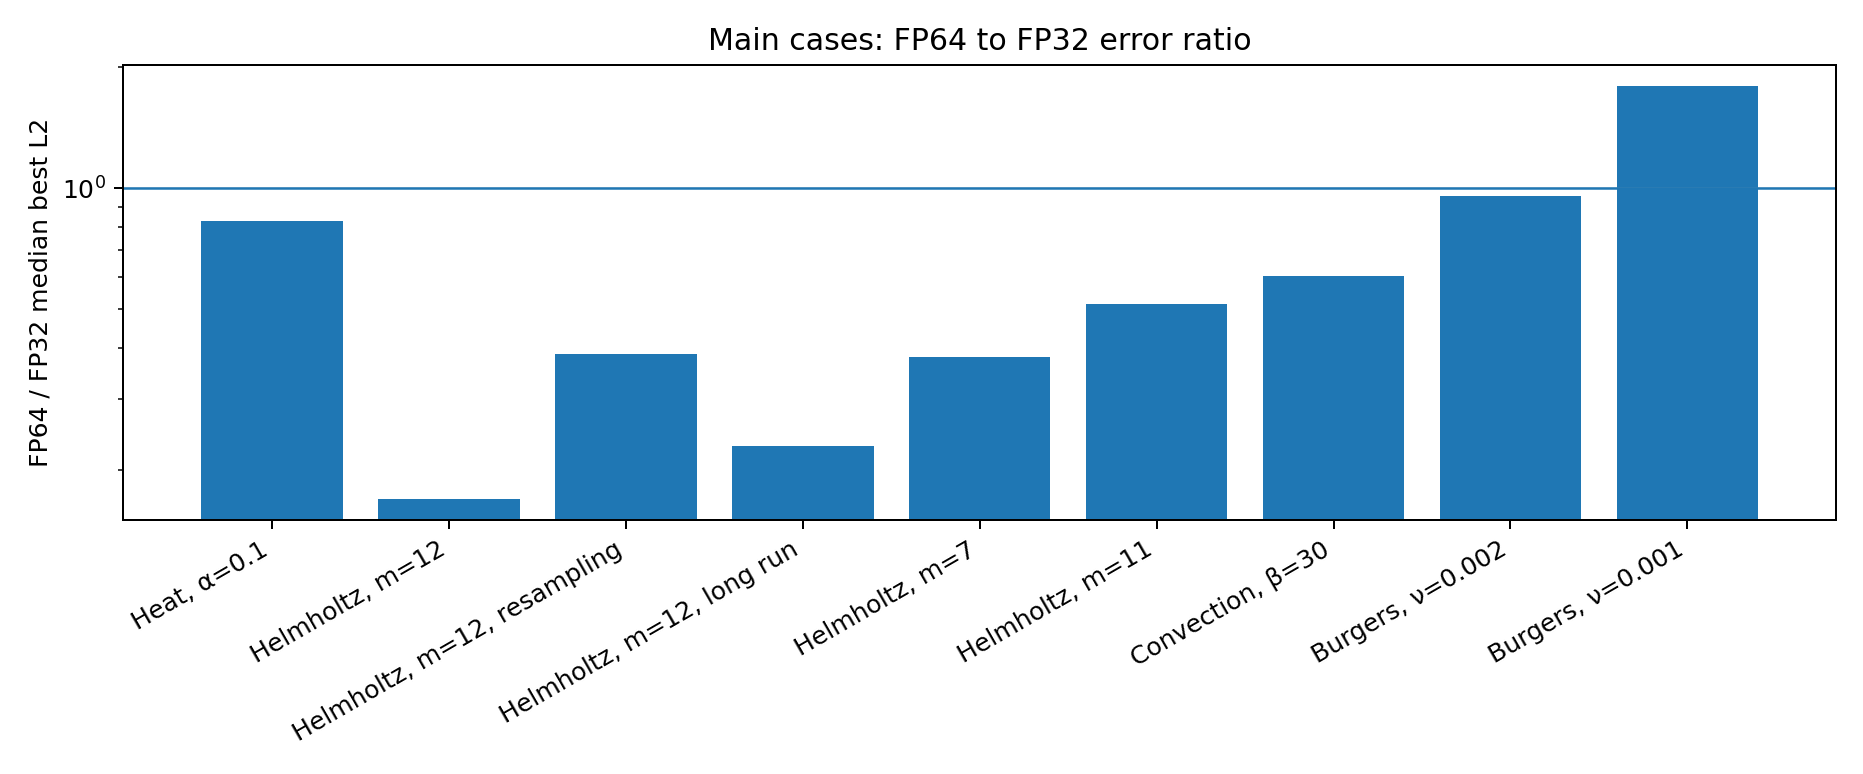

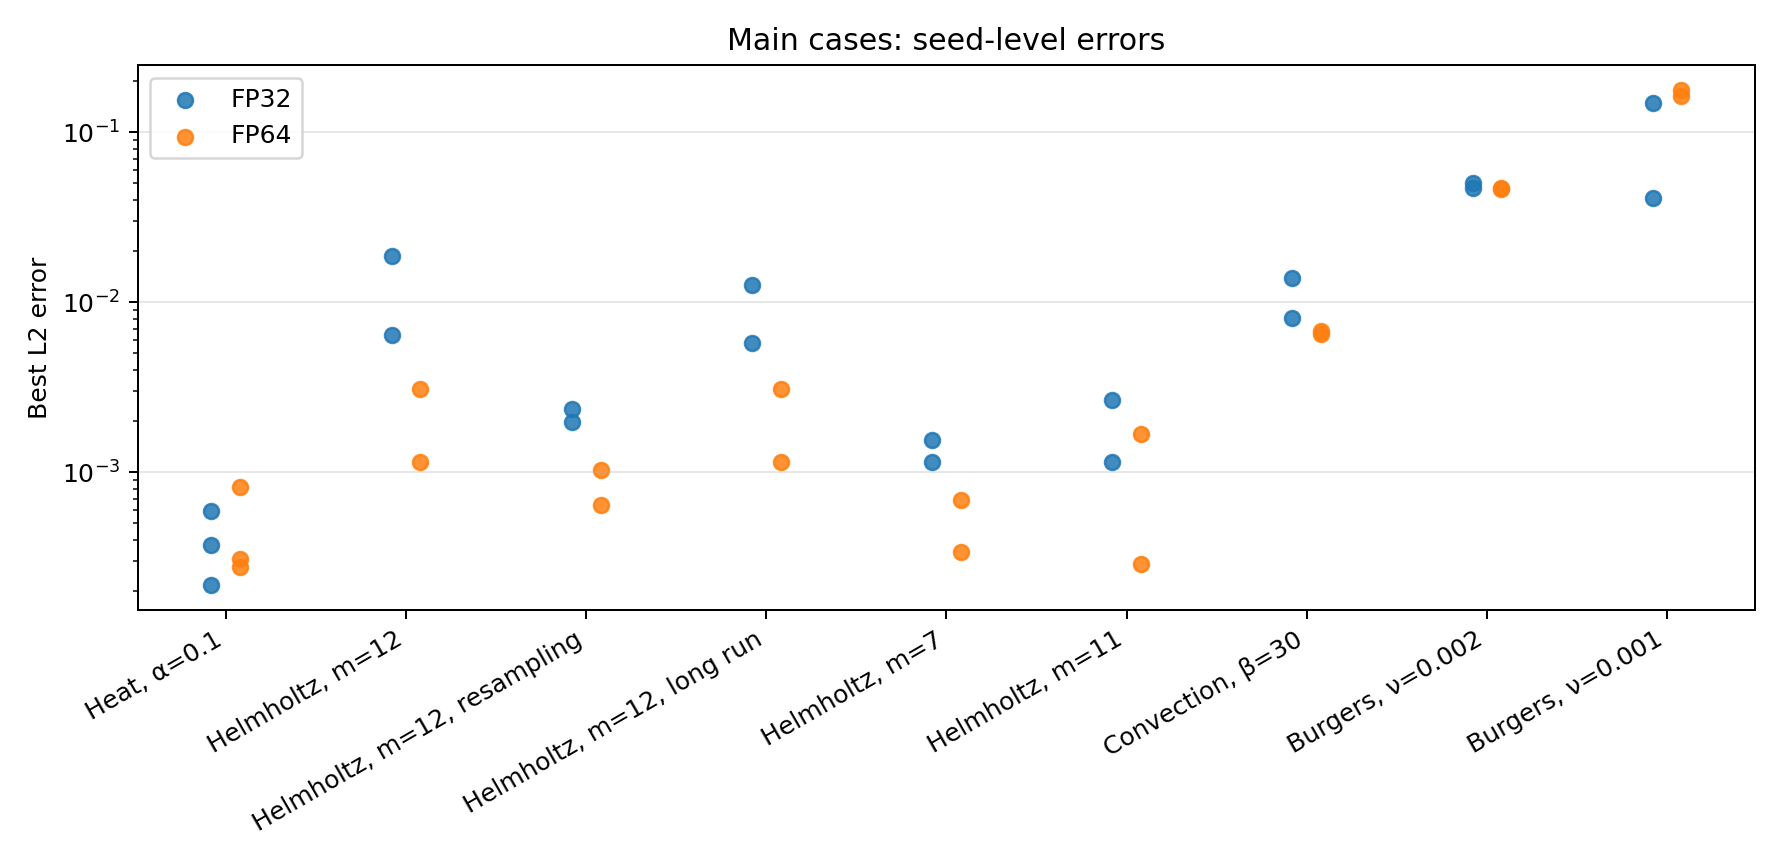

In [16]:
show_img("report_main_best_l2_by_dtype.png")
show_img("report_main_fp64_fp32_ratio.png")
show_img("report_main_seed_scatter.png")


## Карты решений и ошибок

### Сохранённые срезы решений

| Helmholtz FP32 | Helmholtz FP64 |
| --- | --- |
| ![](../report_results/figures/solution_slices/helmholtz_m12_fp32_seed0.png) | ![](../report_results/figures/solution_slices/helmholtz_m12_fp64_seed0.png) |

| Convection beta=30 FP32 | Convection beta=30 FP64 |
| --- | --- |
| ![](../report_results/figures/solution_slices/convection_beta30_fp32_seed0.png) | ![](../report_results/figures/solution_slices/convection_beta30_fp64_seed0.png) |

| Convection beta=50 FP32 | Convection beta=50 FP64 |
| --- | --- |
| ![](../report_results/figures/solution_slices/convection_beta50_fp32_seed0.png) | ![](../report_results/figures/solution_slices/convection_beta50_fp64_seed0.png) |

| Burgers nu=0.002 FP32 | Burgers nu=0.002 FP64 |
| --- | --- |
| ![](../report_results/figures/solution_slices/burgers_nu0p002_fp32_seed0.png) | ![](../report_results/figures/solution_slices/burgers_nu0p002_fp64_seed0.png) |